In [2]:
import numpy as np
import sys
import muram as mio  
import matplotlib.pyplot as plt

In [3]:
# For the SSD data with ch and corona - you can use this path:
#pathsource = '/dat/milic/MURaM_enhanced_network/'
#pathsource =  '/dat/milic/MURAM_SSD_ch_co_25x25x25Mm/'
pathsource = '/dat/milic/'

#Should not need this, but check the structure of the folder
path3D = pathsource + '3D/'
#path2D = pathsource #+ '2D/'

In [9]:
# For the other SSD data, with higher resolution and photospher only, use this path:
pathsource = '/dat/milic/'
path3D = pathsource + '3D/3D_full_subdomain/' # Sorry I was rearranging something there
#path2D = pathsource + '2D/'

In [10]:
# IF you used the first one, it's FULL snaps - so use MuramSnap
#cube = mio.MuramSnap(path3D, 0)
#cube = mio.MuramSnap(path3D, 499000)
# But for the other one, they are so called SUBSNAPS - so you use MuramSubSnap
cube = mio.MuramSubSnap(path3D, 0)


In [11]:
cube.available

['rho',
 'vx',
 'vy',
 'vz',
 'eint',
 'Bx',
 'By',
 'Bz',
 'Temp',
 'Pres',
 'ne',
 'tau']

In [37]:
# Our goal is to extract a simplified 3D cube that contains temperature, vz, Bx,By,Bz for a few different taus. Then, we use this knowledge to train a model 
# to predict the depression of log tau = 1 surface. Which means we also need to calculate z(tau=1,0.1,0.01) for each column, and add it to the cube.

# we will take five after all
log_tau_to_output = [-2.0, -1.5, -1.0, -0.5, 0.0]
#log_tau_to_output = log_tau_to_output[::-1]

# We have tau given in the cube, so we can find the z for each tau by interpolation. We will use the log of tau, so we will interpolate log(tau) vs z, and then find z for the desired log(tau).

T = cube.Temp.transpose(1,2,0)
tau = cube.tau.transpose(1,2,0)
vz = cube.vx.transpose(1,2,0)
Bz = cube.Bx.transpose(1,2,0)
Bx = cube.By.transpose(1,2,0)
By = cube.Bz.transpose(1,2,0)

In [32]:
# Now we allocate a new cube: 

newcube = np.zeros([6, T.shape[0], T.shape[1], len(log_tau_to_output)]) # 5 variables for each tau
newcube.shape

(6, 1536, 1536, 5)

In [22]:
from tqdm import tqdm
z_universal = np.arange(T.shape[2]) * 16E3 # in meters
print (z_universal)

[      0.   16000.   32000.   48000.   64000.   80000.   96000.  112000.
  128000.  144000.  160000.  176000.  192000.  208000.  224000.  240000.
  256000.  272000.  288000.  304000.  320000.  336000.  352000.  368000.
  384000.  400000.  416000.  432000.  448000.  464000.  480000.  496000.
  512000.  528000.  544000.  560000.  576000.  592000.  608000.  624000.
  640000.  656000.  672000.  688000.  704000.  720000.  736000.  752000.
  768000.  784000.  800000.  816000.  832000.  848000.  864000.  880000.
  896000.  912000.  928000.  944000.  960000.  976000.  992000. 1008000.
 1024000. 1040000. 1056000. 1072000. 1088000. 1104000. 1120000. 1136000.
 1152000. 1168000. 1184000. 1200000. 1216000. 1232000. 1248000. 1264000.
 1280000. 1296000. 1312000. 1328000. 1344000. 1360000. 1376000. 1392000.
 1408000. 1424000. 1440000. 1456000. 1472000. 1488000. 1504000. 1520000.
 1536000. 1552000. 1568000. 1584000. 1600000. 1616000. 1632000. 1648000.
 1664000. 1680000. 1696000. 1712000. 1728000. 17440

In [49]:
for i in tqdm(range(T.shape[0])):
    for j in range(T.shape[1]):
        log_tau_column = np.log(tau[i,j,:])

        z_target = np.interp(log_tau_to_output, log_tau_column[::-1], z_universal[::-1])
        newcube[0,i,j,:] = np.interp(log_tau_to_output, log_tau_column[::-1], T[i,j,::-1])        
        newcube[1,i,j,:] = np.interp(log_tau_to_output, log_tau_column[::-1], vz[i,j,::-1])
        newcube[2,i,j,:] = np.interp(log_tau_to_output, log_tau_column[::-1], Bx[i,j,::-1])
        newcube[3,i,j,:] = np.interp(log_tau_to_output, log_tau_column[::-1], By[i,j,::-1])
        newcube[4,i,j,:] = np.interp(log_tau_to_output, log_tau_column[::-1], Bz[i,j,::-1])
        newcube[5,i,j,:] = z_target

100%|██████████| 1536/1536 [01:45<00:00, 14.51it/s]


In [50]:
newcube.shape

(6, 1536, 1536, 5)

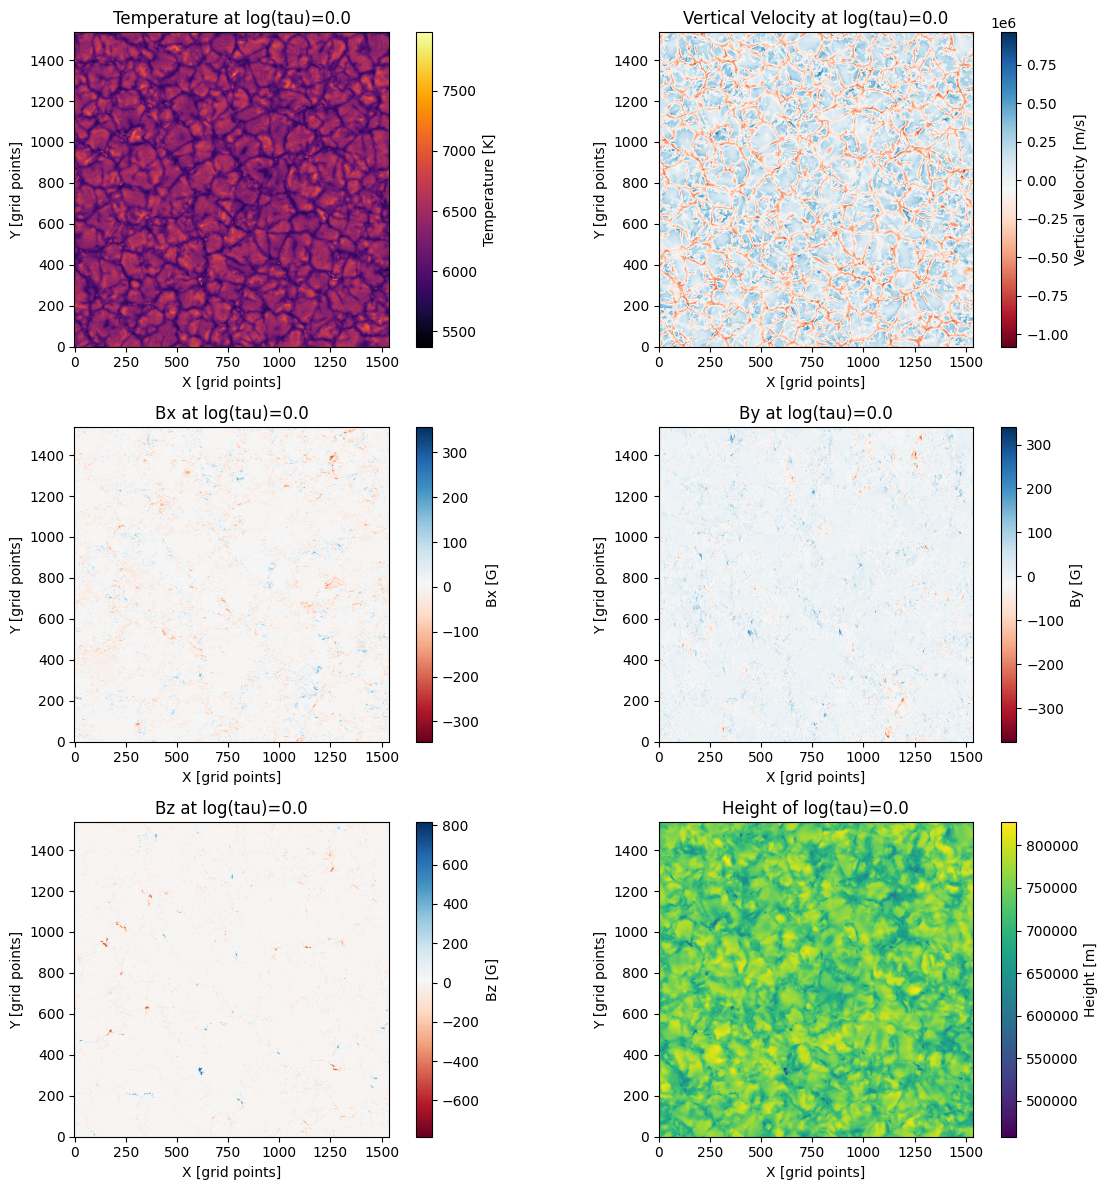

In [51]:
# Let's test the cube for different taus:
tau_index = 4
plt.figure(figsize=(12,12))
plt.subplot(3,2,1)
plt.imshow(newcube[0,:,:,tau_index].T, origin='lower', cmap='inferno')
plt.colorbar(label='Temperature [K]')
plt.title(f'Temperature at log(tau)={log_tau_to_output[tau_index]}')
plt.xlabel('X [grid points]')
plt.ylabel('Y [grid points]')
plt.subplot(3,2,2)
plt.imshow(newcube[1,:,:,tau_index].T, origin='lower', cmap='RdBu')
plt.colorbar(label='Vertical Velocity [m/s]')
plt.title(f'Vertical Velocity at log(tau)={log_tau_to_output[tau_index]}')
plt.xlabel('X [grid points]')
plt.ylabel('Y [grid points]')
plt.subplot(3,2,3)
plt.imshow(newcube[2,:,:,tau_index].T, origin='lower', cmap='RdBu')
plt.colorbar(label='Bx [G]')
plt.title(f'Bx at log(tau)={log_tau_to_output[tau_index]}')
plt.xlabel('X [grid points]')
plt.ylabel('Y [grid points]')
plt.subplot(3,2,4)
plt.imshow(newcube[3,:,:,tau_index].T, origin='lower', cmap='RdBu')
plt.colorbar(label='By [G]')
plt.title(f'By at log(tau)={log_tau_to_output[tau_index]}')
plt.xlabel('X [grid points]')
plt.ylabel('Y [grid points]')
plt.subplot(3,2,5)
plt.imshow(newcube[4,:,:,tau_index].T, origin='lower', cmap='RdBu')
plt.colorbar(label='Bz [G]')
plt.title(f'Bz at log(tau)={log_tau_to_output[tau_index]}')
plt.xlabel('X [grid points]')
plt.ylabel('Y [grid points]')
plt.subplot(3,2,6)
plt.imshow(newcube[5,:,:,tau_index].T, origin='lower', cmap='viridis')
plt.colorbar(label='Height [m]')
plt.title(f'Height of log(tau)={log_tau_to_output[tau_index]}')
plt.xlabel('X [grid points]')
plt.ylabel('Y [grid points]')
plt.tight_layout()
plt.savefig(f'cube_variables_logtau_{log_tau_to_output[tau_index]}.png', dpi=150, bbox_inches='tight')
plt.show()


In [52]:
z_mean_log_tau_0 = np.mean(newcube[5,:,:,4]) # this is the mean height of log(tau)=0 surface
print (f'Mean height of log(tau)=0 surface: {z_mean_log_tau_0:.2f} m')

Mean height of log(tau)=0 surface: 738007.06 m


In [53]:
# subtract that 
newcube[5,:,:,:] = newcube[5,:,:,:] - z_mean_log_tau_0

In [54]:
# Multiply magnetic fields 
newcube[2:5,:,:,:] = newcube[2:5,:,:,:] * np.sqrt(4*np.pi)

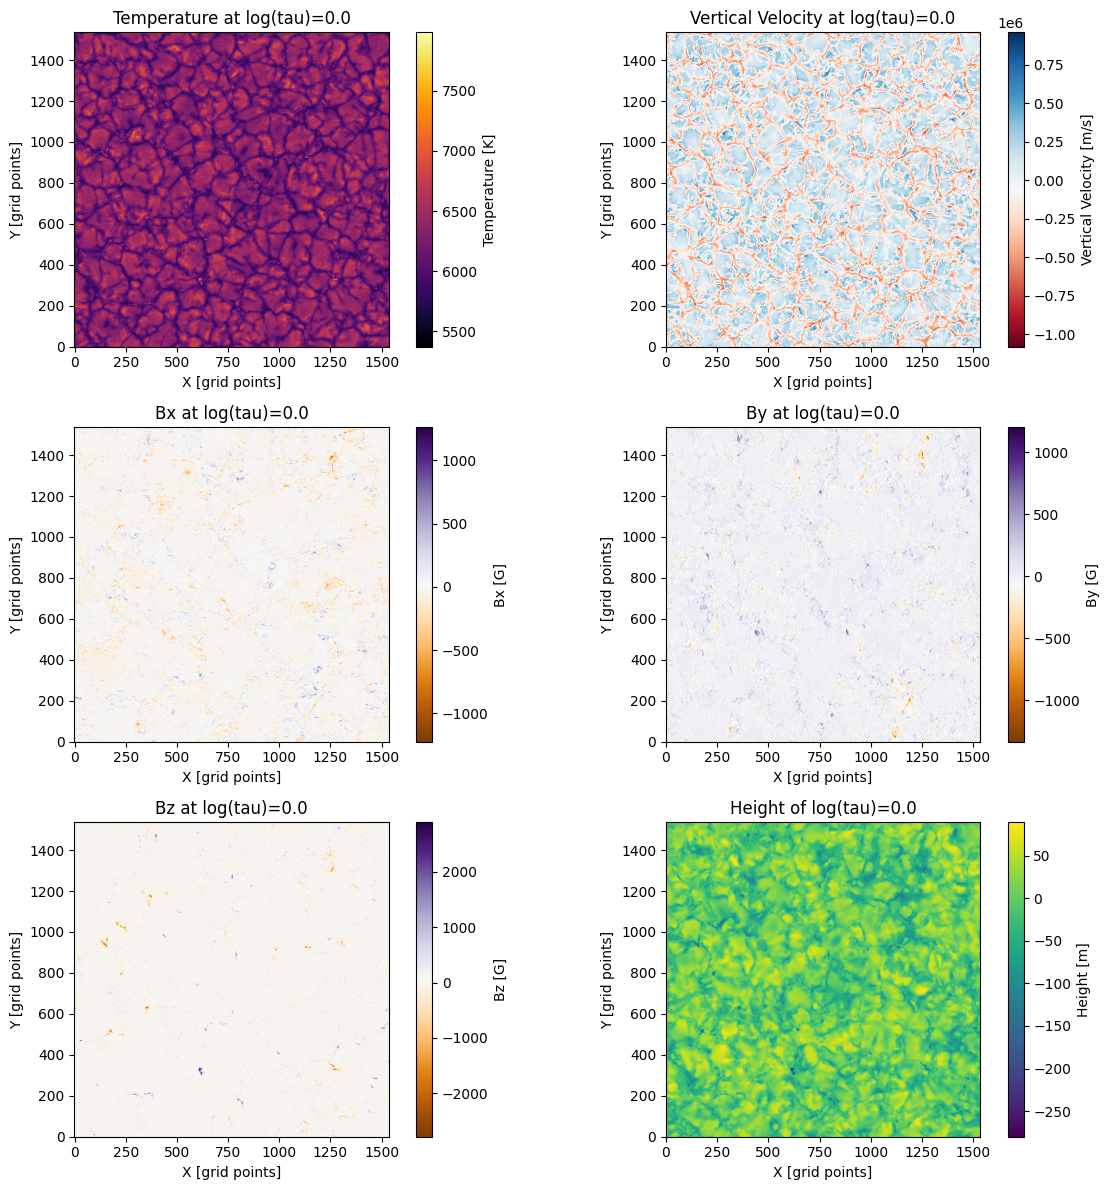

In [ ]:
# Let's test the cube for different taus:
tau_index = 4
plt.figure(figsize=(12,12))
plt.subplot(3,2,1)
plt.imshow(newcube[0,:,:,tau_index].T, origin='lower', cmap='inferno')
plt.colorbar(label='Temperature [K]')
plt.title(f'Temperature at log(tau)={log_tau_to_output[tau_index]}')
plt.xlabel('X [grid points]')
plt.ylabel('Y [grid points]')
plt.subplot(3,2,2)
plt.imshow(newcube[1,:,:,tau_index].T, origin='lower', cmap='RdBu')
plt.colorbar(label='Vertical Velocity [m/s]')
plt.title(f'Vertical Velocity at log(tau)={log_tau_to_output[tau_index]}')
plt.xlabel('X [grid points]')
plt.ylabel('Y [grid points]')
plt.subplot(3,2,3)
plt.imshow(newcube[2,:,:,tau_index].T, origin='lower', cmap='PuOr',vmin=-500, vmax=500)
plt.colorbar(label='Bx [G]')
plt.title(f'Bx at log(tau)={log_tau_to_output[tau_index]}')
plt.xlabel('X [grid points]')
plt.ylabel('Y [grid points]')
plt.subplot(3,2,4)
plt.imshow(newcube[3,:,:,tau_index].T, origin='lower', cmap='PuOr',vmin=-500, vmax=500)
plt.colorbar(label='By [G]')
plt.title(f'By at log(tau)={log_tau_to_output[tau_index]}')
plt.xlabel('X [grid points]')
plt.ylabel('Y [grid points]')
plt.subplot(3,2,5)
plt.imshow(newcube[4,:,:,tau_index].T, origin='lower', cmap='PuOr',vmin=-500, vmax=500)
plt.colorbar(label='Bz [G]')
plt.title(f'Bz at log(tau)={log_tau_to_output[tau_index]}')
plt.xlabel('X [grid points]')
plt.ylabel('Y [grid points]')
plt.subplot(3,2,6)
plt.imshow(newcube[5,:,:,tau_index].T/1E3, origin='lower', cmap='viridis')
plt.colorbar(label='Height [m]')
plt.title(f'Height of log(tau)={log_tau_to_output[tau_index]}')
plt.xlabel('X [grid points]')
plt.ylabel('Y [grid points]')
plt.tight_layout()
plt.savefig(f'cube_variables_logtau_{log_tau_to_output[tau_index]}.png', dpi=150, bbox_inches='tight')
plt.show()
